<a href="https://colab.research.google.com/github/teemus28/Machine-Learning/blob/main/ML_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bagging - Bootstrap Aggregation

#Random Forest - trains bootstraped(random) sample with multiple decision trees and classify based on Aggregation(majority or average of all trees)

#Hyperparameters

#1 n_estimators - no. of trees
#2 max_features - sqrt/log2()
#3 bootstrap - True/False
#4 oob_score - score from left out samples , True/False
#5 n_samples - no. of samples taken for each tree

Classification

In [ ]:
from sklearn.datasets import make_circles

In [ ]:
#np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

In [ ]:
X.shape

(500, 2)

In [ ]:
import matplotlib.pyplot as plt


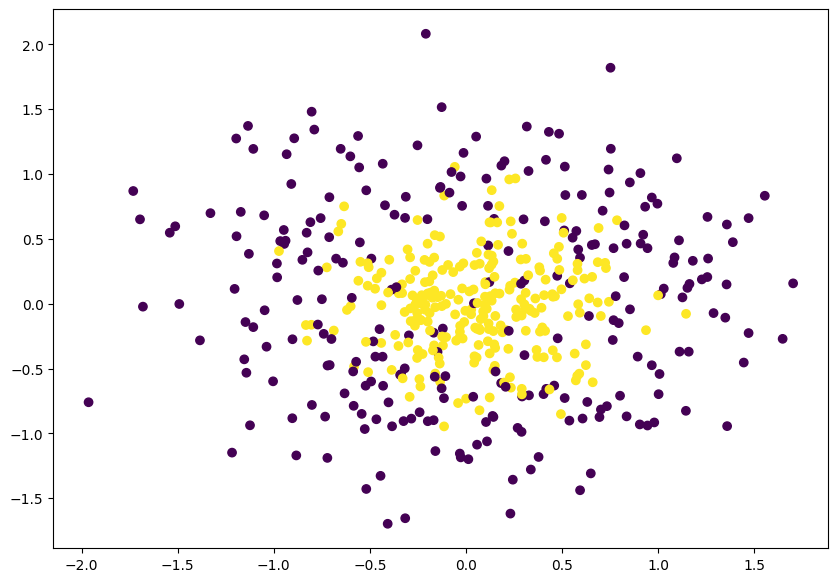

In [ ]:
from matplotlib.pylab import rcParams    #controls size of figure
rcParams['figure.figsize'] = 10,7

plt.scatter(X[:,0],X[:,1],c=y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(max_depth=4)

In [ ]:
dtree.fit(X,y)

DecisionTreeClassifier(max_depth=4)

In [ ]:
import numpy as np

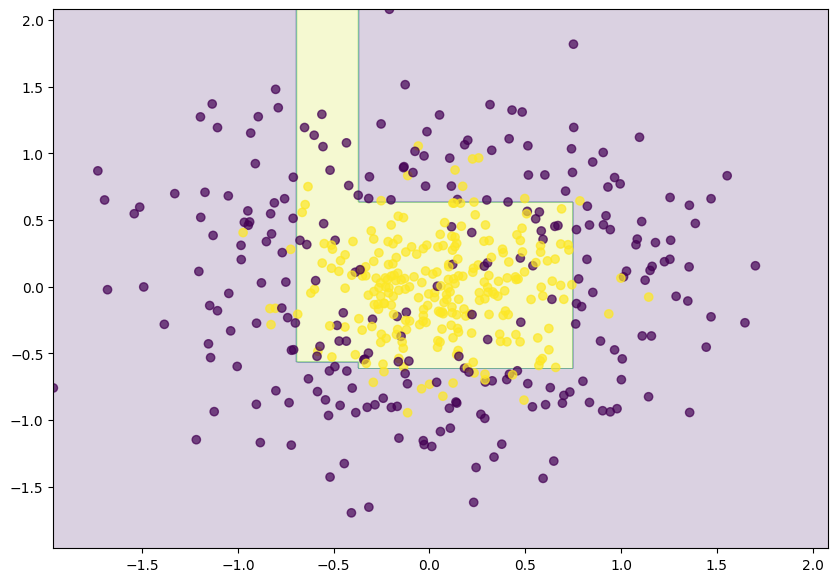

In [ ]:
x_range = np.linspace(X.min(),X.max(),500)
xx1,xx2 = np.meshgrid(x_range,x_range)    #create matrix
y_hat = dtree.predict(np.c_[xx1.ravel(),xx2.ravel()])     #ravel - 2d-1d , c_ - create columns of xx1,xx2
y_hat = y_hat.reshape(xx1.shape)

plt.contourf(xx1,xx2,y_hat,alpha=0.2)    #visualizing classification plot
plt.scatter(X[:,0],X[:,1],c=y, cmap='viridis', alpha=.7)

plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(max_depth=4,n_estimators=20,bootstrap=True,oob_score=True)

In [ ]:
rf.fit(X,y)

RandomForestClassifier(max_depth=4, n_estimators=20, oob_score=True)

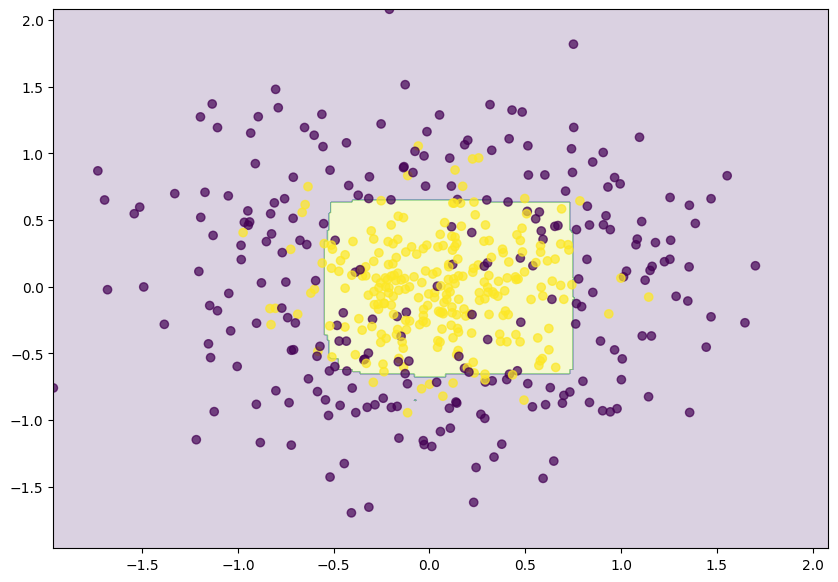

In [ ]:
x_range = np.linspace(X.min(),X.max(),500)
xx1,xx2 = np.meshgrid(x_range,x_range)    #create matrix
y_hat = rf.predict(np.c_[xx1.ravel(),xx2.ravel()])     #ravel - 2d-1d , c_ - create columns of xx1,xx2
y_hat = y_hat.reshape(xx1.shape)

plt.contourf(xx1,xx2,y_hat,alpha=0.2)    #visualizing classification plot
plt.scatter(X[:,0],X[:,1],c=y, cmap='viridis', alpha=.7)

plt.show()

In [ ]:
rf.oob_score_

0.822

In [ ]:
from sklearn.model_selection import GridSearchCV

grid = dict()
grid['max_depth'] = [4,1,8,15]
grid['n_estimators'] = [10, 50, 100, 500]
grid['max_features'] = ['sqrt','log',None]
#grid['max_samples'] = [100,250,400,50,None]
#grid['bootstrap'] = [True , False]
#grid['oob_score'] = [True , False]




grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=grid, n_jobs=-1, cv=10, scoring='accuracy')
# execute the grid search
grid_result = grid_search.fit(X, y)
# summarize the best score and configuration
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
160 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
77 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/utils

Best: 0.830000 using {'max_depth': 4, 'max_features': 'sqrt', 'n_estimators': 500}


Regression

In [ ]:
#  RandomForestRegressor

In [ ]:
def f(x):
  x = x.ravel()
  return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

In [ ]:
X, y = generate(n_samples=X.shape[0], noise=0.1)
noise=0.1

In [ ]:
# X_train, y_train = generate(n_samples=100, noise=noise)
# X_test, y_test = generate(n_samples=20, noise=noise)

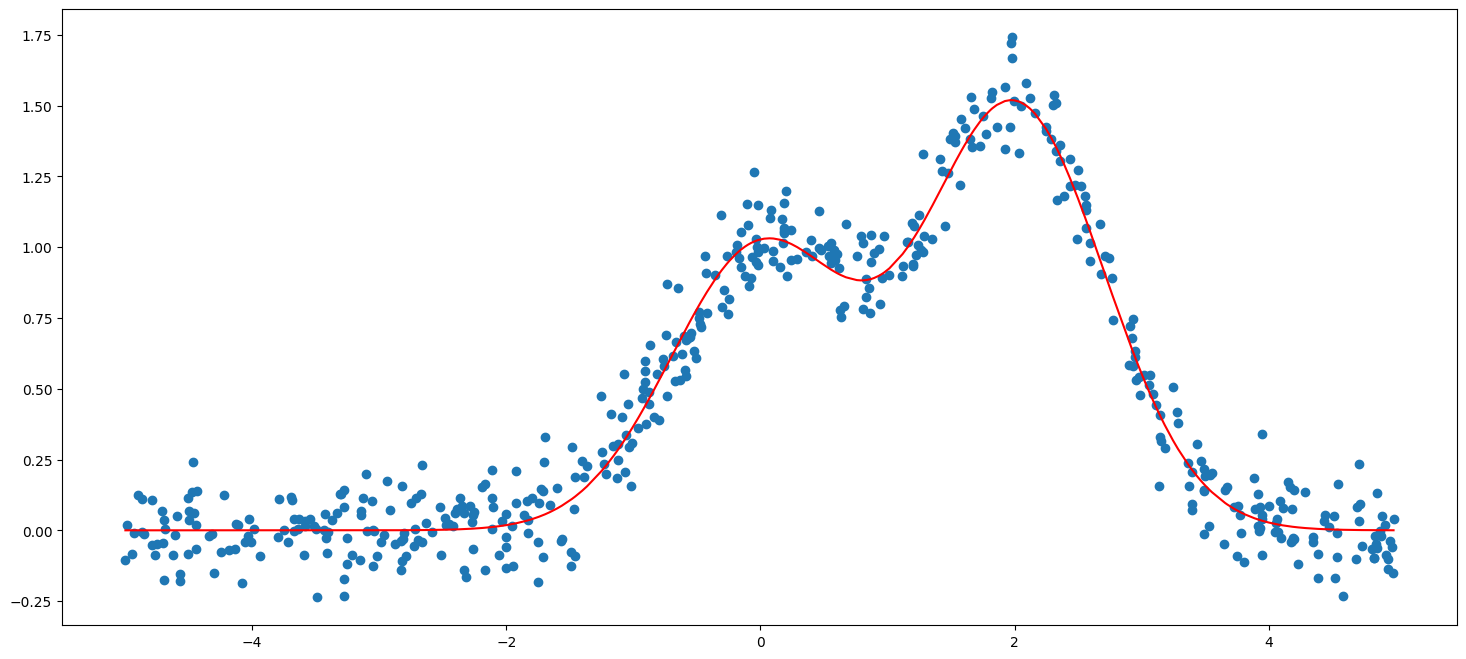

In [ ]:
plt.figure(figsize=(18, 8))
plt.scatter(X,y)
plt.plot(X,f(X),'r')

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
dtree = DecisionTreeRegressor()

In [ ]:
dtree.fit(X,y)

DecisionTreeRegressor()

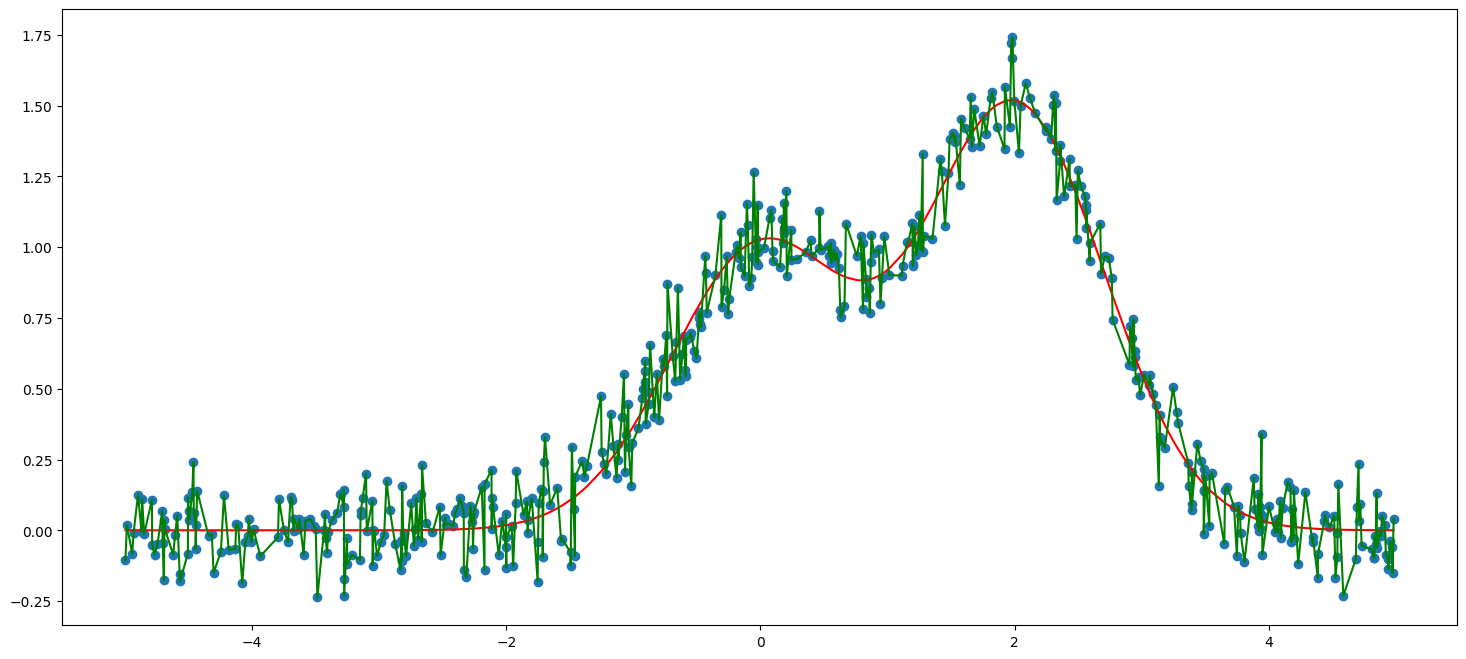

In [ ]:
plt.figure(figsize=(18, 8))
plt.scatter(X,y)
plt.plot(X,f(X),'r')
plt.plot(X,dtree.predict(X),'g')

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()


In [ ]:
rf.fit(X,y)

RandomForestRegressor()

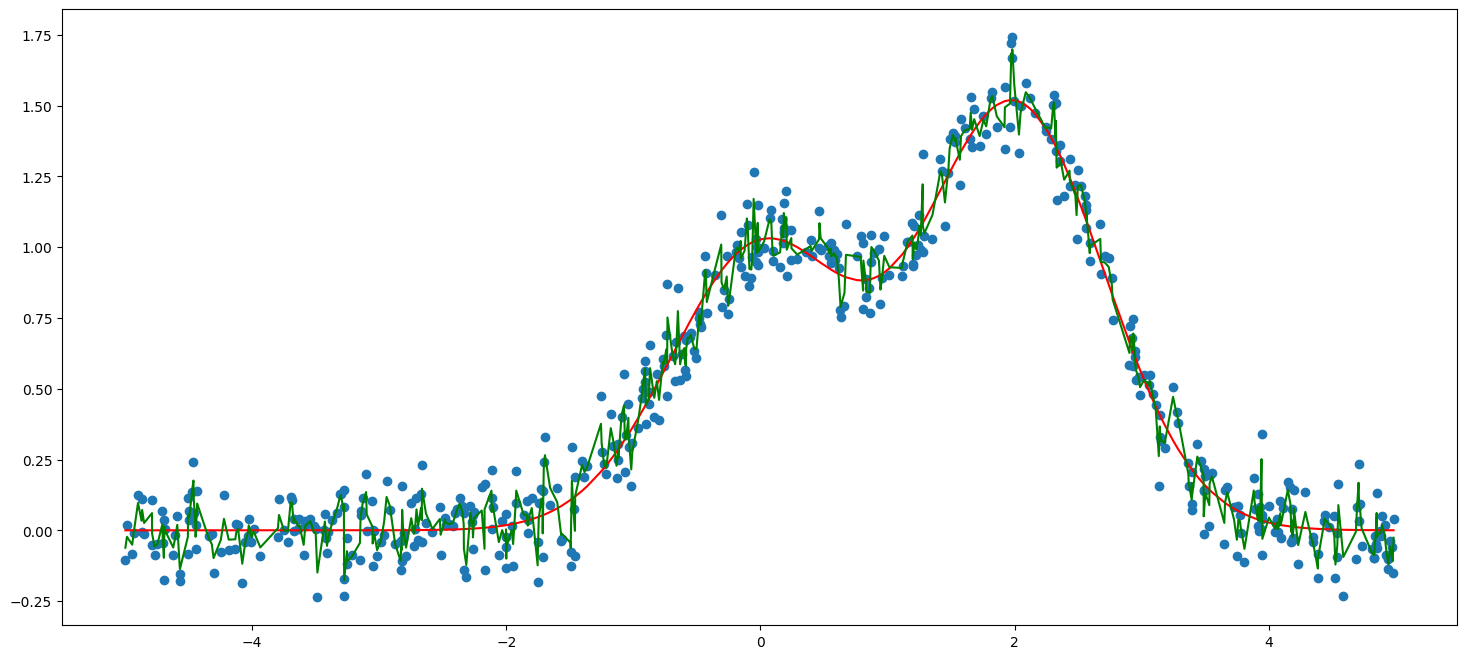

In [ ]:
plt.figure(figsize=(18, 8))
plt.scatter(X,y)
plt.plot(X,f(X),'r')
plt.plot(X,rf.predict(X),'g')